In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazonreviews/test.ft.txt.bz2
/kaggle/input/amazonreviews/train.ft.txt.bz2


# IMPORTS

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import bz2
import csv
import re

2025-08-08 03:13:11.191338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754622791.524930      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754622791.618758      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# LOADING DATASET

In [3]:
import bz2


# Load a subset of the training data
with bz2.BZ2File("/kaggle/input/amazonreviews/train.ft.txt.bz2") as f:
    training_data = [f.readline().decode('utf-8').strip() for _ in range(12000)]

# Load a subset of the test data
with bz2.BZ2File("/kaggle/input/amazonreviews/test.ft.txt.bz2") as f:
    test_data = [f.readline().decode('utf-8').strip() for _ in range(2500)]

# Print the subset sizes
print("Training data subset size:", len(training_data))
print("Test data subset size:", len(test_data))

Training data subset size: 12000
Test data subset size: 2500


# Preparing Dataset

In [4]:
training_data[0:5]

['__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^',
 "__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",
 '__label__2 Amazing!: This sound

In [5]:
# Split the data into labels and texts
training_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in training_data]
training_texts = [re.sub(r'__label__\d ', '', line) for line in training_data]

test_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in test_data]
test_texts = [re.sub(r'__label__\d ', '', line) for line in test_data]

# Convert labels to binary (0 and 1)
training_labels = [0 if label == 1 else 1 for label in training_labels]
test_labels = [0 if label == 1 else 1 for label in test_labels]

In [6]:
test_labels[:20]

[1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1]

# Text Cleaning

# STOPWORD STEMMING AND LOWER CASING

In [7]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

def clean_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    # Join words back into a string
    return " ".join(words)

# Apply function to training and test texts
training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
training_texts[0]

'stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen'

# Tokenization

In [9]:
# Tokenization and padding
max_words = 1000
max_sequence_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)

X_train = tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)


In [10]:
X_train = np.array(X_train)
print(X_train.shape)
X_test = np.array(X_test)
print(X_test.shape)
y_train = np.array(training_labels)
print(y_train.shape)
y_test = np.array(test_labels)
print(y_test.shape)

(12000, 100)
(2500, 100)
(12000,)
(2500,)


# Training RNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1754622823.093276      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754622823.094159      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1754622829.705829     100 service.cc:148] XLA service 0x7f7c44007580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754622829.707032     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1754622829.707058     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1754622830.582181     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/24 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4868 - loss: 0.9106 

I0000 00:00:1754622835.129070     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.4964 - loss: 0.8876 - val_accuracy: 0.5180 - val_loss: 0.7420
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5027 - loss: 0.8286 - val_accuracy: 0.5144 - val_loss: 0.6963
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5165 - loss: 0.7697 - val_accuracy: 0.5252 - val_loss: 0.6922
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5123 - loss: 0.7533 - val_accuracy: 0.5288 - val_loss: 0.6928
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5022 - loss: 0.7439 - val_accuracy: 0.5240 - val_loss: 0.6928
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5172 - loss: 0.7296 - val_accuracy: 0.5300 - val_loss: 0.6906
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5097 - loss: 0.7283 - val_accuracy: 0.5400 - val_loss: 0.6885
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5177 - loss: 0.7217 - val_accuracy: 0.5496 - val_loss: 

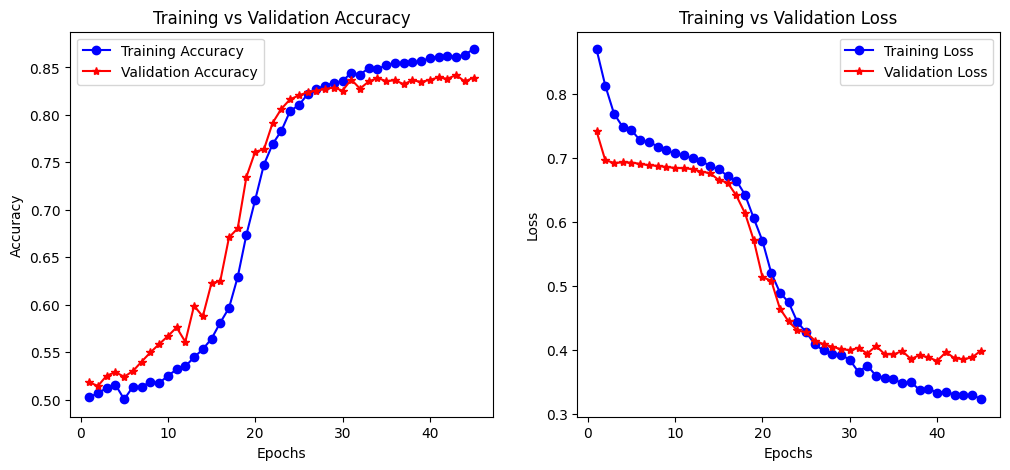

In [11]:
# Define improved RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    SimpleRNN(128, return_sequences=True, dropout=0.3),  # RNN layer with dropout
    LayerNormalization(),  # Added normalization for stability
    SimpleRNN(128, dropout=0.3),  # Second RNN layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [12]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Confusion Matrix:
[[ 954  237]
 [ 171 1138]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1191
           1       0.83      0.87      0.85      1309

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500



# Training LSTM

In [13]:
# Define improved model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),  # Added recurrent dropout
    LayerNormalization(),  # Added normalization for stability
    Dropout(0.3),
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),  
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 938ms/step - accuracy: 0.5226 - loss: 0.8839 - val_accuracy: 0.5936 - val_loss: 0.6672
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 859ms/step - accuracy: 0.5429 - loss: 0.7255 - val_accuracy: 0.6260 - val_loss: 0.6547
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 872ms/step - accuracy: 0.5794 - loss: 0.6785 - val_accuracy: 0.6800 - val_loss: 0.6287
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 860ms/step - accuracy: 0.6272 - loss: 0.6441 - val_accuracy: 0.7156 - val_loss: 0.5838
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 868ms/step - accuracy: 0.6770 - loss: 0.5929 - val_accuracy: 0.7432 - val_loss: 0.5292
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 865ms/step - accuracy: 0.7200 - loss: 0.5505 - val_accuracy: 0.7592 - val_loss: 0.4925
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 853ms/step - accuracy: 0.7568 - loss: 0.5004 - val_accuracy: 0.7840 - val_loss: 0.4578
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 859ms/step - accuracy: 0.7907 - loss: 0.4547 - val_accuracy: 0.800

# Model Evaluation

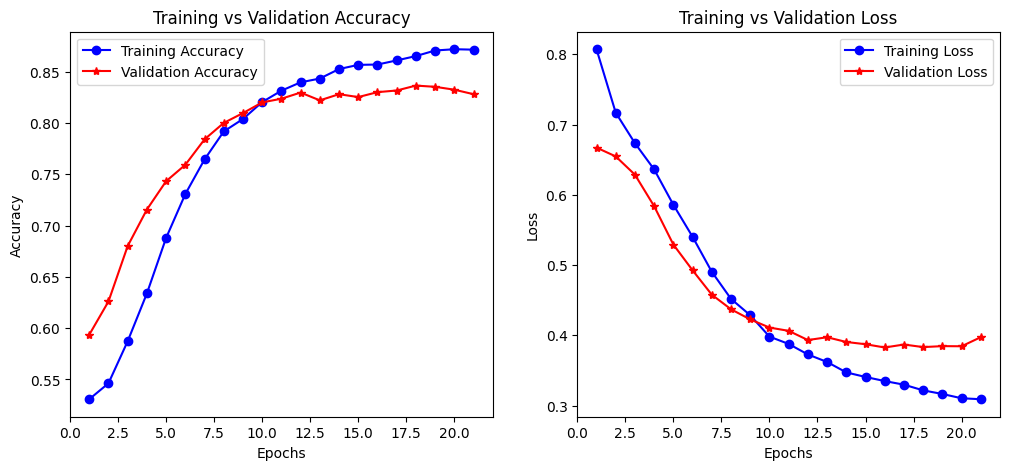

In [14]:
import matplotlib.pyplot as plt

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [15]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step
Confusion Matrix:
[[ 947  244]
 [ 181 1128]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1191
           1       0.82      0.86      0.84      1309

    accuracy                           0.83      2500
   macro avg       0.83      0.83      0.83      2500
weighted avg       0.83      0.83      0.83      2500



# Training GRU

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 549ms/step - accuracy: 0.5061 - loss: 0.9998 - val_accuracy: 0.5476 - val_loss: 0.7424
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - accuracy: 0.5370 - loss: 0.8118 - val_accuracy: 0.5868 - val_loss: 0.7118
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - accuracy: 0.5678 - loss: 0.7479 - val_accuracy: 0.6104 - val_loss: 0.6689
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step - accuracy: 0.5871 - loss: 0.7245 - val_accuracy: 0.6352 - val_loss: 0.6491
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 498ms/step - accuracy: 0.5935 - loss: 0.7099 - val_accuracy: 0.6456 - val_loss: 0.6311
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 476ms/step - accuracy: 0.6037 - loss: 0.6965 - val_accuracy: 0.6552 - val_loss: 0.6203
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.6146 - loss: 0.6787 - val_accuracy: 0.6628 - val_loss: 0.6096
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 492ms/step - accuracy: 0.6171 - loss: 0.6714 - val_accuracy: 0.671

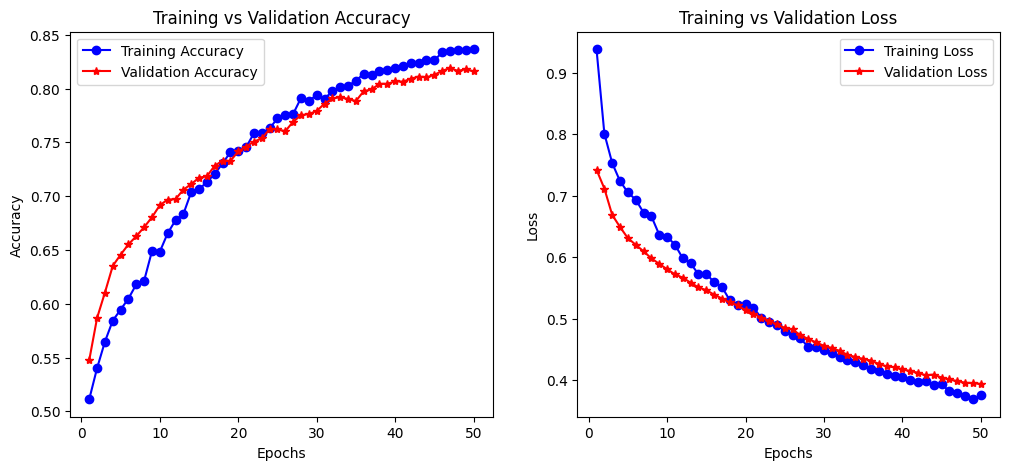

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step
Confusion Matrix:
[[ 934  257]
 [ 203 1106]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1191
           1       0.81      0.84      0.83      1309

    accuracy                           0.82      2500
   macro avg       0.82      0.81      0.82      2500
weighted avg       0.82      0.82      0.82      2500



In [16]:


# Define improved GRU model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),  # GRU layer with dropout
    LayerNormalization(),  # Added normalization for stability
    GRU(128, dropout=0.3, recurrent_dropout=0.2),  # Second GRU layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()



# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

# Training Bidirectional LSTM

In [ ]:
# Define Bidirectional LSTM model
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),  # First Bidirectional LSTM layer
    LayerNormalization(),  # Added normalization for stability
    Dropout(0.3),
    Bidirectional(LSTM(64, recurrent_dropout=0.2)),  # Second Bidirectional LSTM layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model_bilstm.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Print model summary
print("Bidirectional LSTM Model Summary:")
model_bilstm.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
print("\nTraining Bidirectional LSTM Model...")
history_bilstm = model_bilstm.fit(X_train, y_train, epochs=50, batch_size=512, 
                                  validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

In [ ]:
# Extract values from history
epochs = range(1, len(history_bilstm.history['accuracy']) + 1)
train_acc = history_bilstm.history['accuracy']
val_acc = history_bilstm.history['val_accuracy']
train_loss = history_bilstm.history['loss']
val_loss = history_bilstm.history['val_loss']

# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Bidirectional LSTM - Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Bidirectional LSTM - Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate with confusion matrix and classification report
print("\nEvaluating Bidirectional LSTM Model...")
y_pred_bilstm = model_bilstm.predict(X_test)
y_pred_bilstm_binary = (y_pred_bilstm > 0.5)

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm_binary)
print("\nBidirectional LSTM - Confusion Matrix:")
print(cm_bilstm)

report_bilstm = classification_report(y_test, y_pred_bilstm_binary)
print("\nBidirectional LSTM - Classification Report:")
print(report_bilstm)

# Calculate and print accuracy
accuracy_bilstm = (y_pred_bilstm_binary == y_test.reshape(-1, 1)).mean()
print(f"\nBidirectional LSTM Test Accuracy: {accuracy_bilstm:.4f}")

# Model Comparison

In [ ]:
# Note: You'll need to store model histories and predictions from previous models to run this comparison
# This is a template for comparing all models

# Store model names and their corresponding objects (you may need to retrain to get all histories)
model_names = ['RNN', 'LSTM', 'GRU', 'Bidirectional LSTM']

# Example comparison (you'll need to adapt this based on your stored results)
print("Model Performance Comparison:")
print("="*50)

# If you have stored the results from previous models, you can compare them here
# For now, let's just show the Bidirectional LSTM results
print(f"Bidirectional LSTM Test Accuracy: {accuracy_bilstm:.4f}")

# You can add more comparison metrics here when you have results from all models
print("\nTo get complete comparison, please run all models and store their results.")

# Save the Bidirectional LSTM model
model_bilstm.save("bidirectional_lstm_model.h5")
print("\nBidirectional LSTM model saved as 'bidirectional_lstm_model.h5'")

# Detection System

In [17]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):
    # clean text
    text = clean_text(text)
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])
    
    # Pad sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)
    
    # Predict sentiment
    prediction = model.predict(padded_sequence)[0][0]  # Extract scalar value
    
    # Determine sentiment
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😡"
    
    return sentiment, float(prediction)

# Example usage:
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.9926)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.0016)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Negative 😡 (Confidence: 0.3980)



In [18]:
model.save("lstm_model.h5")  # Saves architecture, weights & optimizer


import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [19]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [22]:
import tensorflow as tf
print(tf.__version__)

2.18.0
